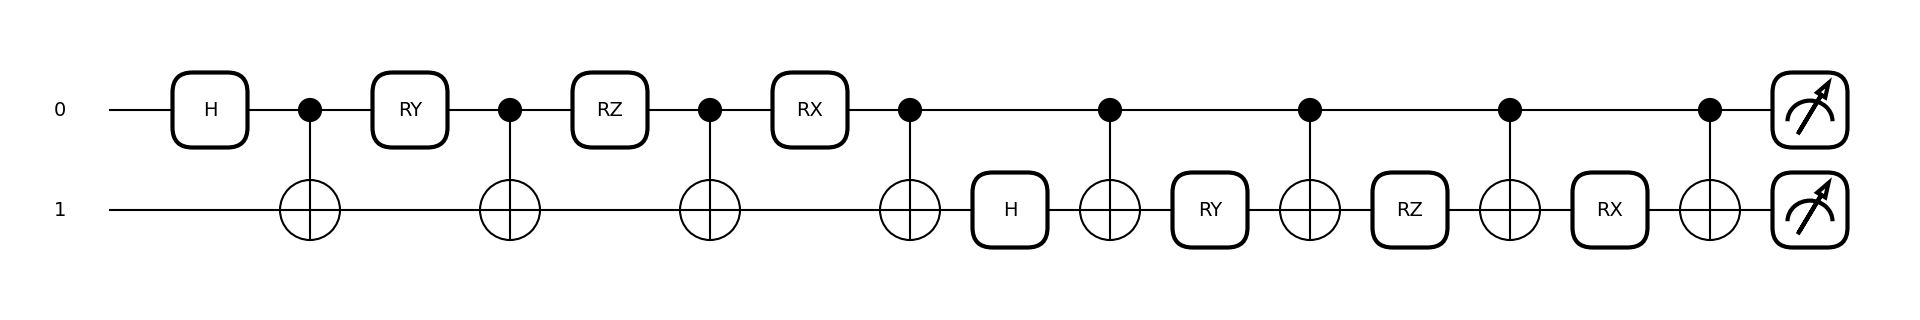

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\1002-ORIGIN-2D electronic properties2.csv",encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]



# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x)

# Quantum setup
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[0, 1])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
y_train=(y)

In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)



,kernel,'precomputed'
,degree,3
,gamma,2.0881963569756823
,coef0,0.0
,tol,0.001
,C,977
,epsilon,0.07491851902055541
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


train r^2: 0.4025389506204107
train MAE 0.7691397832941202
train RMSE: 1.0667238924292364


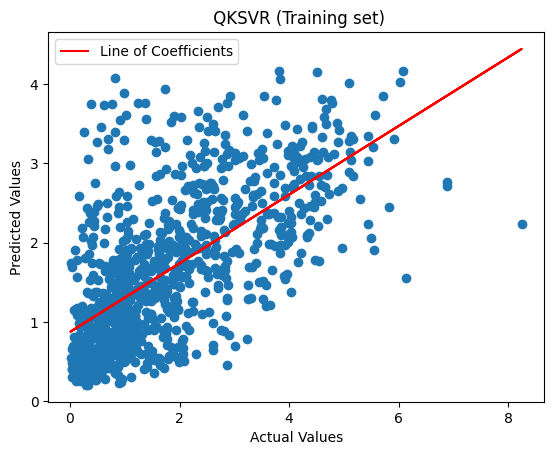

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QKSVR (Training set)")#title
plt.legend()

In [5]:
df_true50=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-50-EXTERNAL DATA.csv",encoding='ISO-8859–1')    
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df_true50['Band gap ']

# defining target
x2=df_true50[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [1.02098695 0.76888308 1.07450637 1.23286877 0.93798856 1.20962288
 1.23690105 1.480963   3.06501559 2.10942864 1.64208103 0.7617938
 1.72196485 0.19748152 0.63464989 0.16867188 1.28905406 0.52487227
 0.30443642 3.28770534 1.31988667 2.38980032 3.18876719 2.20993483
 1.66280116 1.39934589 0.6014316  0.51044611 2.26387221 2.64310732
 3.68281071 0.79760063 1.32581002 2.48390105 1.1006175  0.64079709
 0.21928532 3.19695994 3.0905141  2.94257471 2.22093779 1.56862896
 0.51038235 1.08924795 1.15936694 1.39295505 1.49480004 0.84932286
 1.68331981 4.05644412]


Model evaluation - Test Set-TEV-50:
r^2: 0.18695328497953712
MAE 0.7911330451475286
RMSE: 1.1377027105768998


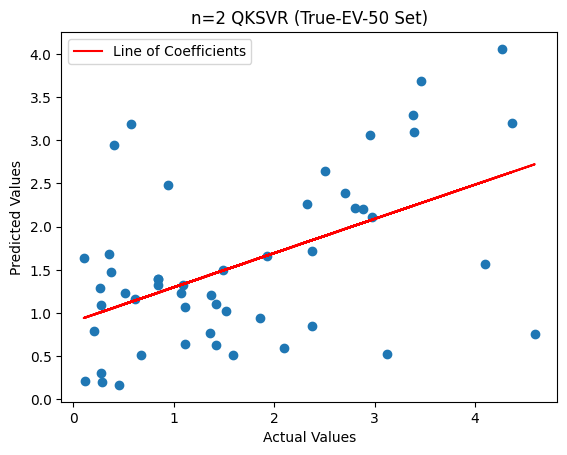

In [13]:

print("Model evaluation - Test Set-TEV-50:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=2 QKSVR (True-EV-50 Set)")#title
plt.legend()

In [7]:
df3=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-100-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [3.77379935 2.02332948 1.23228151 1.26797945 3.66169444 1.82943229
 3.71350938 1.34650616 1.02951423 0.60995821 1.05081667 0.76515418
 0.64081081 0.27463879 0.89867727 1.94836958 0.87205578 0.81005612
 2.7840612  2.20354804 2.61348142 0.76992692 1.88782056 3.44135909
 0.93914432 2.1038245  2.92310898 3.24910285 1.59656507 2.09309419
 1.65638783 3.76703494 2.41349138 2.35655056 2.23980799 0.65304614
 0.96869019 0.7657986  1.45285131 1.30830467 2.29025064 1.28237366
 0.50320298 1.17692253 2.02818288 1.82666591 1.94440005 0.4320325
 0.60351243 1.03292426 0.27042346 0.69522167 0.4521805  0.64761976
 0.17292161 1.0988274  2.9551511  0.76226361 0.68588376 1.51190051
 1.29949549 1.37948326 1.14478274 1.59671355 0.45904304 1.81625579
 2.55725041 1.34619688 2.10895331 3.33056856 1.39182019 3.11516701
 0.78876065 1.53967106 2.48670218 3.1121809  2.01173506 2.05310247
 0.75419791 0.91394167 0.18358673 0.38848073 0.42325976 1.35932731
 0.75468112 0.80126952 1.99686748 0.94479327 

Model evaluation - Test Set:TEV-100
r^2: 0.45249345316388745
MAE 0.7880129862327988
RMSE: 1.1734607761213116


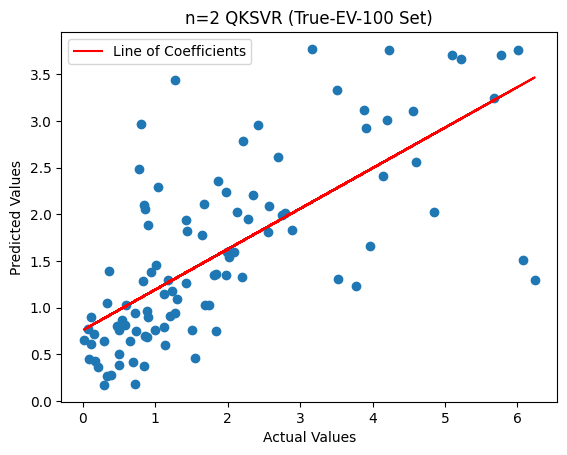

In [14]:

print("Model evaluation - Test Set:TEV-100")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=2 QKSVR (True-EV-100 Set)")#title
plt.legend()

In [9]:

df4=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-250-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [1.73820939 2.16762075 0.96074146 0.91655345 1.08027984 1.61270119
 2.36662917 1.27136886 0.89884762 3.85693611 0.44260662 3.36626401
 0.77311589 0.44664186 0.38515983 0.71169793 2.55081012 0.82588642
 0.8418632  1.37574669 3.3807987  0.73297966 3.05542677 1.29785695
 1.64659927 1.45658022 3.09307103 1.31854656 2.8970536  2.70135456
 0.95819229 2.97019878 1.28071638 0.58390099 2.70626757 0.96757838
 0.66739272 0.86076951 1.63026147 1.81121954 0.6819719  0.84792039
 0.72141278 1.422762   1.76584197 2.96660948 0.5666857  1.19232697
 1.82586144 0.4247185  0.7077065  2.09752439 0.35610965 0.58595619
 0.73802664 3.13341764 1.20290132 1.53634174 1.31598404 1.8842451
 2.4041451  1.32720309 2.25433679 0.72065096 0.64997627 1.78681612
 1.67213446 1.28151663 2.6680593  1.3580403  0.47206663 3.33552204
 2.0297678  0.69239908 1.31069817 0.68438699 0.95802516 0.89927514
 1.54596469 0.72557243 0.96089299 0.21823986 1.29425529 3.82819473
 2.01227841 1.74330106 1.72625201 3.56671684 

Model evaluation - Test Set:TEV-250
r^2: 0.34863677183083064
MAE 0.8082269778164491
RMSE: 1.1806481218486844


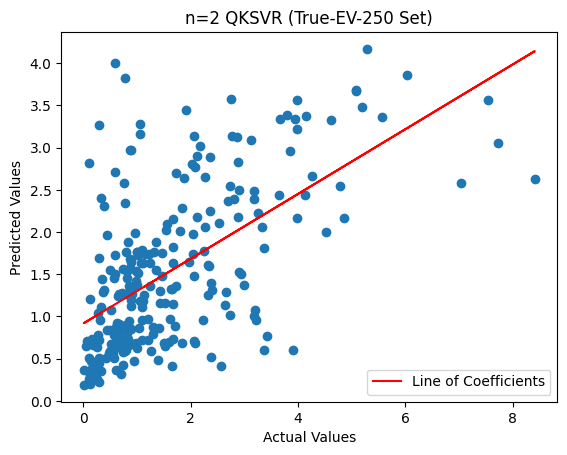

In [15]:

print("Model evaluation - Test Set:TEV-250")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("n=2 QKSVR (True-EV-250 Set)")#title
plt.legend()

In [11]:
df5=pd.read_csv(r"C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\other qubit variation using optimized hyp\study-fm-pro\TRUE-EXTERNAL VALIDATION\TRUE-400-EXTERNAL DATA.csv",encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [1.02098695 0.76888308 1.07450637 1.23286877 0.93798856 1.20962288
 1.23690105 1.480963   3.06501559 2.10942864 1.64208103 0.7617938
 1.72196485 0.19748152 0.63464989 0.16867188 1.28905406 0.52487227
 0.30443642 3.28770534 1.31988667 2.38980032 3.18876719 2.20993483
 1.66280116 1.39934589 0.6014316  0.51044611 2.26387221 2.64310732
 3.68281071 0.79760063 1.32581002 2.48390105 1.1006175  0.64079709
 0.21928532 3.19695994 3.0905141  2.94257471 2.22093779 1.56862896
 0.51038235 1.08924795 1.15936694 1.39295505 1.49480004 0.84932286
 1.68331981 4.05644412 3.77379935 2.02332948 1.23228151 1.26797945
 3.66169444 1.82943229 3.71350938 1.34650616 1.02951423 0.60995821
 1.05081667 0.76515418 0.64081081 0.27463879 0.89867727 1.94836958
 0.87205578 0.81005612 2.7840612  2.20354804 2.61348142 0.76992692
 1.88782056 3.44135909 0.93914432 2.1038245  2.92310898 3.24910285
 1.59656507 2.09309419 1.65638783 3.76703494 2.41349138 2.35655056
 2.23980799 0.65304614 0.96869019 0.7657986  

Model evaluation - Test Set: TEV-400
r^2: 0.36677474699439805
MAE 0.8010367383369215
RMSE: 1.1735649631554603


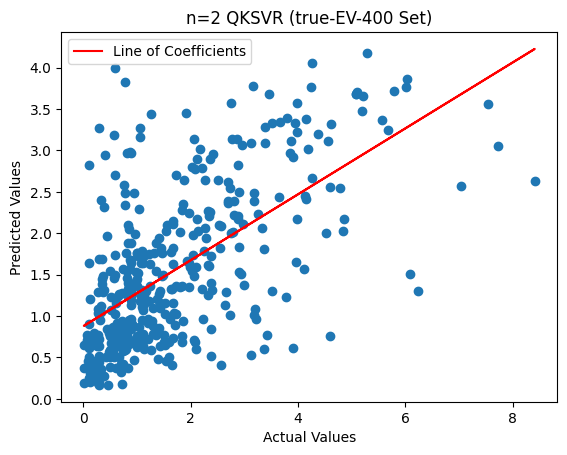

In [16]:

print("Model evaluation - Test Set: TEV-400")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("n=2 QKSVR (true-EV-400 Set)")#title
plt.legend()